---
<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=300>

# **<big><big>Algoritmos y Programación III</big></big>**
**Proyecto final — Clasificación de calidad de frutas**

---

- **Martinez Vasquez Luna Catalina - A00401964**<br>
- **Mosquera Daza Renzo Fernando - A00401681**<br>
- **Tobar Gómez Valentina - A00401749**<br>

---

# Notebook 03 — Modelos de Machine Learning tradicionales


## 1. Propósito

- **Random Forest**, porque permite capturar relaciones no lineales entre los píxeles y suele ser robusto frente a variaciones visuales.
- **Support Vector Machine**, porque busca una frontera de separación con margen máximo y es una alternativa razonable frente a KNN cuando no queremos comparar cada imagen nueva contra todo el conjunto de entrenamiento.

## 2. Importación de librerías

Se cargan las librerías para leer los metadatos procesados, vectorizar las imágenes, entrenar modelos, ajustar hiperparámetros y guardar los modelos que usará la aplicación.

In [9]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from IPython.display import display

import joblib
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 90)
pd.set_option("display.max_rows", 90)
pd.set_option("display.max_colwidth", 180)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
RANDOM_STATE = 42

## 3. Rutas y parámetros

Se usan los archivos creados por el Notebook 02. No se vuelve a dividir el dataset ni se repite el EDA. El tamaño de entrada para los modelos tradicionales se fija en 48 x 48 para reducir el costo computacional de SVM y Random Forest sin romper la compatibilidad con la aplicación.

In [10]:
PROJECT_ROOT = Path.cwd().parent
ANNOTATIONS_DIR = PROJECT_ROOT / "data" / "annotations"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

TRAIN_PATH = ANNOTATIONS_DIR / "train_metadata.csv"
VAL_PATH = ANNOTATIONS_DIR / "val_metadata.csv"
TEST_PATH = ANNOTATIONS_DIR / "test_metadata.csv"
SUMMARY_PATH = TABLES_DIR / "03_model_comparison.csv"

MODEL_IMAGE_SIZE = 48
CV_FOLDS = 3
SCORING = "f1_macro"
QUALITY_LABELS = ["bad", "regular", "good"]
SIZE_LABELS = ["small", "medium", "large"]

for directory in [MODELS_DIR, FIGURES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Proyecto:", PROJECT_ROOT)
print("Train:", TRAIN_PATH)
print("Validation:", VAL_PATH)
print("Test:", TEST_PATH)
print("Tamaño de entrada:", f"{MODEL_IMAGE_SIZE}x{MODEL_IMAGE_SIZE}")

Proyecto: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3
Train: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\train_metadata.csv
Validation: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\val_metadata.csv
Test: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\test_metadata.csv
Tamaño de entrada: 48x48


## 4. Carga de metadatos procesados

El contrato de entrada exige que existan `processed_relative_path`, `quality_label` y `size_label`, porque esas columnas fueron generadas en el Notebook 02.

In [11]:
def read_metadata(path, split_name):
    if not path.exists():
        raise FileNotFoundError(f"No existe {path}. Ejecuta primero el Notebook 02.")
    data = pd.read_csv(path)
    data["split"] = split_name
    return data

train_df = read_metadata(TRAIN_PATH, "train")
val_df = read_metadata(VAL_PATH, "val")
test_df = read_metadata(TEST_PATH, "test")

required_columns = {"processed_relative_path", "quality_label", "size_label"}
missing_columns = required_columns - set(train_df.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas en los metadatos procesados: {sorted(missing_columns)}")

metadata_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

display(metadata_df.groupby(["split", "quality_label"]).size().unstack(fill_value=0).reindex(index=["train", "val", "test"], columns=QUALITY_LABELS, fill_value=0))
display(metadata_df.groupby(["split", "size_label"]).size().unstack(fill_value=0).reindex(index=["train", "val", "test"], columns=SIZE_LABELS, fill_value=0))

quality_label,bad,regular,good
split,,,
train,938,2766,1577
val,313,922,526
test,313,922,526


size_label,small,medium,large
split,,,
train,1763,1759,1759
val,588,587,586
test,588,587,586


## 5. Vectorización compatible con la aplicación

Cada imagen procesada se abre en RGB, se ajusta a 48 x 48, se normaliza entre 0 y 1 y se convierte en un vector. Ese mismo contrato queda guardado en el archivo `.json` de configuración de cada modelo para que la aplicación pueda aplicar el mismo preprocesamiento.

In [12]:
def image_path_from_relative(relative_path):
    path = Path(str(relative_path).replace(chr(92), "/").strip())
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path


def image_to_vector(relative_path):
    image_path = image_path_from_relative(relative_path)
    with Image.open(image_path) as image:
        image = ImageOps.exif_transpose(image).convert("RGB")
        image = ImageOps.pad(image, (MODEL_IMAGE_SIZE, MODEL_IMAGE_SIZE), color=(255, 255, 255), centering=(0.5, 0.5))
    array = np.asarray(image).astype("float32") / 255.0
    return array.reshape(-1)


def build_matrix(data, name):
    vectors = []
    total = len(data)
    for index, relative_path in enumerate(data["processed_relative_path"], start=1):
        vectors.append(image_to_vector(relative_path))
        if index % 500 == 0 or index == total:
            print(f"{name}: {index}/{total}", end="")
    print()
    return np.vstack(vectors).astype("float32")

X_train = build_matrix(train_df, "train")
X_val = build_matrix(val_df, "val")
X_test = build_matrix(test_df, "test")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

train: 500/5281train: 1000/5281train: 1500/5281train: 2000/5281train: 2500/5281train: 3000/5281train: 3500/5281train: 4000/5281train: 4500/5281train: 5000/5281train: 5281/5281
val: 500/1761val: 1000/1761val: 1500/1761val: 1761/1761
test: 500/1761test: 1000/1761test: 1500/1761test: 1761/1761
X_train: (5281, 6912)
X_val: (1761, 6912)
X_test: (1761, 6912)


## 6. Variables objetivo

Se entrenan dos tareas separadas: calidad (`bad`, `regular`, `good`) y tamaño relativo (`small`, `medium`, `large`).

In [13]:
y_train_quality = train_df["quality_label"].astype(str).values
y_val_quality = val_df["quality_label"].astype(str).values
y_test_quality = test_df["quality_label"].astype(str).values

y_train_size = train_df["size_label"].astype(str).values
y_val_size = val_df["size_label"].astype(str).values
y_test_size = test_df["size_label"].astype(str).values

targets = {
    "quality": {
        "train": y_train_quality,
        "val": y_val_quality,
        "test": y_test_quality,
        "labels": QUALITY_LABELS,
        "label_name": "quality_label"
    },
    "size": {
        "train": y_train_size,
        "val": y_val_size,
        "test": y_test_size,
        "labels": SIZE_LABELS,
        "label_name": "size_label"
    }
}

for target_name, target_data in targets.items():
    print(target_name)
    display(pd.Series(target_data["train"]).value_counts().reindex(target_data["labels"], fill_value=0).to_frame("train"))

quality


,train
bad,938
regular,2766
good,1577


size


,train
small,1763
medium,1759
large,1759


## 7. Funciones de entrenamiento y evaluación

Se usa `accuracy` como lectura general, pero la métrica principal de selección es `f1_macro`, porque el EDA mostró desbalance entre clases y no conviene que una clase mayoritaria domine toda la evaluación.

In [14]:
def available_cv(y):
    counts = pd.Series(y).value_counts()
    minimum = int(counts.min())
    if minimum < 2:
        raise ValueError("No hay suficientes ejemplos por clase para validación cruzada estratificada.")
    return StratifiedKFold(n_splits=min(CV_FOLDS, minimum), shuffle=True, random_state=RANDOM_STATE)


def build_random_forest_grid(y):
    pipeline = Pipeline([
        ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced_subsample", n_jobs=-1))
    ])
    params = {
        "classifier__n_estimators": [150, 250],
        "classifier__max_depth": [None, 20],
        "classifier__min_samples_leaf": [1, 2],
        "classifier__max_features": ["sqrt"]
    }
    return GridSearchCV(pipeline, params, scoring=SCORING, cv=available_cv(y), n_jobs=-1, refit=True, verbose=1)


def build_svm_grid(y):
    pipeline = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("classifier", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=6000))
    ])
    params = {
        "classifier__C": [0.05, 0.2, 1.0]
    }
    return GridSearchCV(pipeline, params, scoring=SCORING, cv=available_cv(y), n_jobs=-1, refit=True, verbose=1)


def evaluate_model(model, X, y, model_name, target_name, dataset_name, labels):
    prediction = model.predict(X)
    return {
        "target": target_name,
        "dataset": dataset_name,
        "model": model_name,
        "accuracy": accuracy_score(y, prediction),
        "precision_macro": precision_score(y, prediction, average="macro", zero_division=0),
        "recall_macro": recall_score(y, prediction, average="macro", zero_division=0),
        "f1_macro": f1_score(y, prediction, average="macro", zero_division=0),
        "f1_weighted": f1_score(y, prediction, average="weighted", zero_division=0),
        "kappa": cohen_kappa_score(y, prediction),
        "labels": ", ".join(labels)
    }


def show_confusion_matrix(model, X, y, labels, model_name, target_name, dataset_name):
    prediction = model.predict(X)
    ConfusionMatrixDisplay.from_predictions(y, prediction, labels=labels, normalize=None, colorbar=False)
    plt.title(f"{target_name} | {model_name} | {dataset_name}")
    plt.tight_layout()
    figure_path = FIGURES_DIR / f"03_confusion_{target_name}_{model_name.lower().replace(' ', '_')}_{dataset_name}.png"
    plt.savefig(figure_path, dpi=160)
    plt.show()
    print(classification_report(y, prediction, labels=labels, zero_division=0))

## 8. Línea base

La línea base predice siempre la clase más frecuente. Sirve para comprobar que Random Forest y SVM realmente estén aprendiendo patrones visuales y no solo replicando el desbalance del dataset.

In [15]:
baseline_rows = []
baseline_models = {}

for target_name, target_data in targets.items():
    dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
    dummy.fit(X_train, target_data["train"])
    baseline_models[target_name] = dummy
    baseline_rows.append(evaluate_model(dummy, X_val, target_data["val"], "Baseline mayoría", target_name, "val", target_data["labels"]))
    baseline_rows.append(evaluate_model(dummy, X_test, target_data["test"], "Baseline mayoría", target_name, "test", target_data["labels"]))

baseline_results = pd.DataFrame(baseline_rows)
display(baseline_results)

,target,dataset,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,kappa,labels
0,quality,val,Baseline mayoría,0.523566,0.174522,0.333333,0.229097,0.359842,0.0,"bad, regular, good"
1,quality,test,Baseline mayoría,0.523566,0.174522,0.333333,0.229097,0.359842,0.0,"bad, regular, good"
2,size,val,Baseline mayoría,0.333901,0.111300,0.333333,0.166880,0.167164,0.0,"small, medium, large"
3,size,test,Baseline mayoría,0.333901,0.111300,0.333333,0.166880,0.167164,0.0,"small, medium, large"


## 9. Entrenamiento de Random Forest y SVM

Los hiperparámetros se ajustan con validación cruzada sobre entrenamiento. Después se comparan en validación y prueba usando las mismas métricas.

In [16]:
trained_models = {}
model_rows = []

for target_name, target_data in targets.items():
    print("Entrenando Random Forest para", target_name)
    rf_grid = build_random_forest_grid(target_data["train"])
    rf_grid.fit(X_train, target_data["train"])
    trained_models[(target_name, "Random Forest")] = rf_grid.best_estimator_
    print("Mejores parámetros RF:", rf_grid.best_params_)
    print("Mejor CV RF:", rf_grid.best_score_)

    print("Entrenando SVM para", target_name)
    svm_grid = build_svm_grid(target_data["train"])
    svm_grid.fit(X_train, target_data["train"])
    trained_models[(target_name, "SVM lineal")] = svm_grid.best_estimator_
    print("Mejores parámetros SVM:", svm_grid.best_params_)
    print("Mejor CV SVM:", svm_grid.best_score_)

    for model_name in ["Random Forest", "SVM lineal"]:
        model = trained_models[(target_name, model_name)]
        model_rows.append(evaluate_model(model, X_train, target_data["train"], model_name, target_name, "train", target_data["labels"]))
        model_rows.append(evaluate_model(model, X_val, target_data["val"], model_name, target_name, "val", target_data["labels"]))
        model_rows.append(evaluate_model(model, X_test, target_data["test"], model_name, target_name, "test", target_data["labels"]))

model_results = pd.concat([baseline_results, pd.DataFrame(model_rows)], ignore_index=True)
model_results["accuracy"] = model_results["accuracy"].round(4)
model_results["precision_macro"] = model_results["precision_macro"].round(4)
model_results["recall_macro"] = model_results["recall_macro"].round(4)
model_results["f1_macro"] = model_results["f1_macro"].round(4)
model_results["f1_weighted"] = model_results["f1_weighted"].round(4)
model_results["kappa"] = model_results["kappa"].round(4)
model_results.to_csv(SUMMARY_PATH, index=False, encoding="utf-8")

display(model_results.sort_values(["target", "dataset", "f1_macro"], ascending=[True, True, False]))
print("Comparación guardada en:", SUMMARY_PATH)

Entrenando Random Forest para quality
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros RF: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 250}
Mejor CV RF: 0.9506877569220062
Entrenando SVM para quality
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Mejores parámetros SVM: {'classifier__C': 0.05}
Mejor CV SVM: 0.8681633637363383
Entrenando Random Forest para size
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros RF: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 250}
Mejor CV RF: 0.7494713558297761
Entrenando SVM para size
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Mejores parámetros SVM: {'classifier__C': 0.05}
Mejor CV SVM: 0.6076636680580871


C:\Users\renzi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\renzi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\renzi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\r

,target,dataset,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,kappa,labels
6,quality,test,Random Forest,0.9580,0.9470,0.9432,0.9450,0.9579,0.9303,"bad, regular, good"
9,quality,test,SVM lineal,0.9012,0.8768,0.8757,0.8761,0.9007,0.8367,"bad, regular, good"
1,quality,test,Baseline mayoría,0.5236,0.1745,0.3333,0.2291,0.3598,0.0000,"bad, regular, good"
7,quality,train,SVM lineal,0.9996,0.9993,0.9998,0.9995,0.9996,0.9994,"bad, regular, good"
4,quality,train,Random Forest,0.9991,0.9989,0.9987,0.9988,0.9991,0.9984,"bad, regular, good"
5,quality,val,Random Forest,0.9620,0.9514,0.9494,0.9503,0.9620,0.9370,"bad, regular, good"
8,quality,val,SVM lineal,0.8910,0.8639,0.8569,0.8600,0.8898,0.8191,"bad, regular, good"
0,quality,val,Baseline mayoría,0.5236,0.1745,0.3333,0.2291,0.3598,0.0000,"bad, regular, good"
12,size,test,Random Forest,0.7598,0.7609,0.7598,0.7575,0.7575,0.6397,"small, medium, large"
15,size,test,SVM lineal,0.6167,0.6148,0.6167,0.6152,0.6152,0.4250,"small, medium, large"


Comparación guardada en: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\results\tables\03_model_comparison.csv


## 10. Matrices de confusión

Se revisa la prueba final para identificar qué clases se confunden más. Esta parte se debe usar después en el informe para hablar de generalización, sobreajuste y errores del modelo.

C:\Users\renzi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\renzi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\renzi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\r

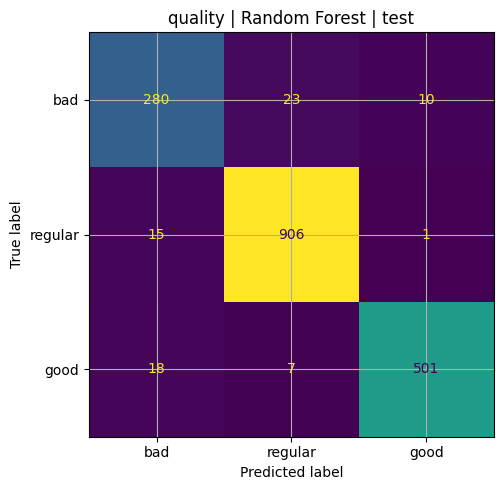

              precision    recall  f1-score   support

         bad       0.89      0.89      0.89       313
     regular       0.97      0.98      0.98       922
        good       0.98      0.95      0.97       526

    accuracy                           0.96      1761
   macro avg       0.95      0.94      0.95      1761
weighted avg       0.96      0.96      0.96      1761



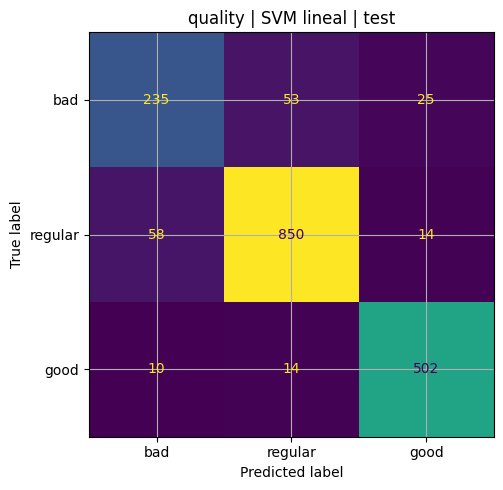

              precision    recall  f1-score   support

         bad       0.78      0.75      0.76       313
     regular       0.93      0.92      0.92       922
        good       0.93      0.95      0.94       526

    accuracy                           0.90      1761
   macro avg       0.88      0.88      0.88      1761
weighted avg       0.90      0.90      0.90      1761



C:\Users\renzi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\renzi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\renzi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\r

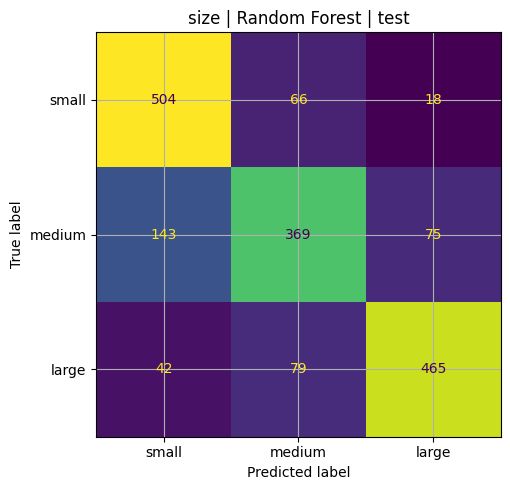

              precision    recall  f1-score   support

       small       0.73      0.86      0.79       588
      medium       0.72      0.63      0.67       587
       large       0.83      0.79      0.81       586

    accuracy                           0.76      1761
   macro avg       0.76      0.76      0.76      1761
weighted avg       0.76      0.76      0.76      1761



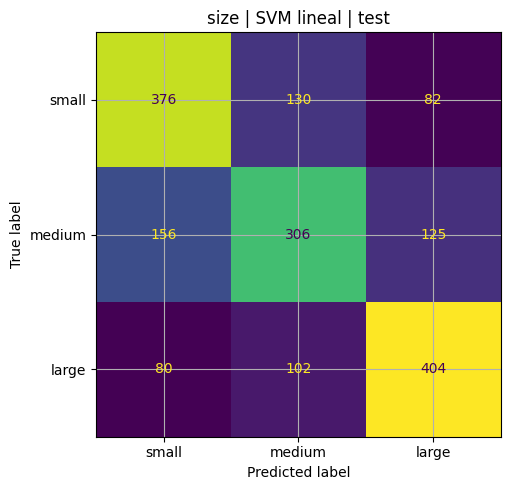

              precision    recall  f1-score   support

       small       0.61      0.64      0.63       588
      medium       0.57      0.52      0.54       587
       large       0.66      0.69      0.68       586

    accuracy                           0.62      1761
   macro avg       0.61      0.62      0.62      1761
weighted avg       0.61      0.62      0.62      1761



In [17]:
for target_name, target_data in targets.items():
    test_results = model_results[(model_results["target"] == target_name) & (model_results["dataset"] == "test") & (model_results["model"].isin(["Random Forest", "SVM lineal"]))]
    ordered_models = test_results.sort_values("f1_macro", ascending=False)["model"].tolist()
    for model_name in ordered_models:
        show_confusion_matrix(trained_models[(target_name, model_name)], X_test, target_data["test"], target_data["labels"], model_name, target_name, "test")

## 11. Comparación visual de resultados

La gráfica resume el `f1_macro` en validación y prueba. Si hay mucha diferencia entre entrenamiento y prueba, se interpreta como posible sobreajuste.

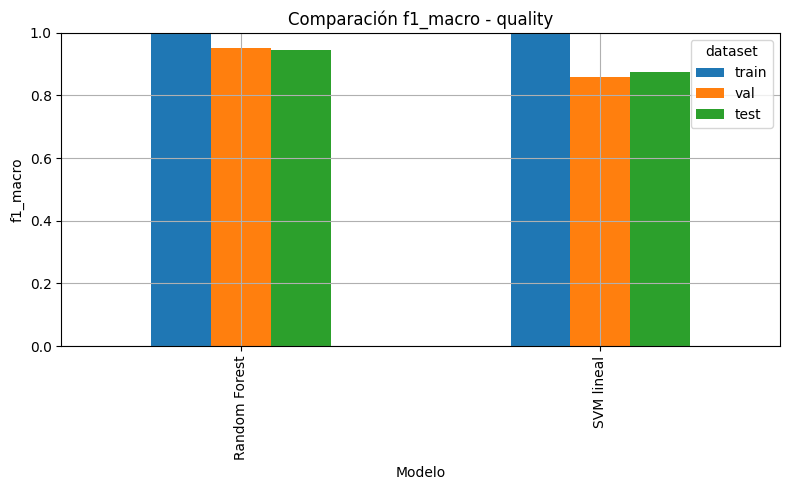

dataset,train,val,test
model,,,
Random Forest,0.9988,0.9503,0.9450
SVM lineal,0.9995,0.8600,0.8761


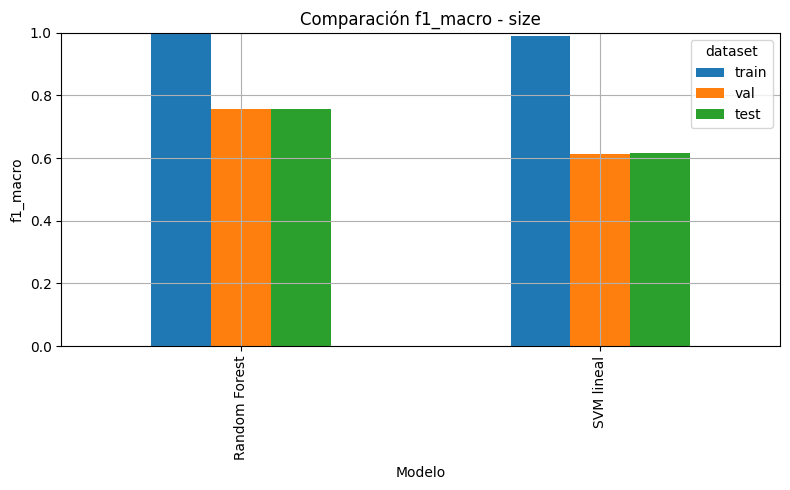

dataset,train,val,test
model,,,
Random Forest,1.0000,0.7558,0.7575
SVM lineal,0.9905,0.6124,0.6152


In [18]:
plot_df = model_results[model_results["model"].isin(["Random Forest", "SVM lineal"])]
for target_name in ["quality", "size"]:
    local = plot_df[(plot_df["target"] == target_name) & (plot_df["dataset"].isin(["train", "val", "test"]))]
    pivot = local.pivot(index="model", columns="dataset", values="f1_macro").reindex(columns=["train", "val", "test"])
    ax = pivot.plot(kind="bar")
    ax.set_title(f"Comparación f1_macro - {target_name}")
    ax.set_xlabel("Modelo")
    ax.set_ylabel("f1_macro")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"03_f1_macro_{target_name}.png", dpi=160)
    plt.show()
    display(pivot)

## 12. Selección de modelos para la aplicación

Se guardan los modelos entrenados en `models/` junto con su configuración. La aplicación puede cargar modelos `.pkl` y leer el `.json` asociado para saber el tamaño de imagen, las clases y si el modelo corresponde a calidad o tamaño.

In [19]:
def save_model(model, filename, target_name, labels, family):
    model_path = MODELS_DIR / filename
    config_path = MODELS_DIR / f"{model_path.stem}_config.json"
    joblib.dump(model, model_path)
    config = {
        "task": target_name,
        "target": target_name,
        "classes": labels,
        "labels": labels,
        "quality_labels": labels if target_name == "quality" else QUALITY_LABELS,
        "size_labels": labels if target_name == "size" else SIZE_LABELS,
        "img_size": [MODEL_IMAGE_SIZE, MODEL_IMAGE_SIZE],
        "image_size": [MODEL_IMAGE_SIZE, MODEL_IMAGE_SIZE],
        "color_mode": "RGB",
        "scale": 255.0,
        "flatten": True,
        "model_family": family,
        "preprocessing": "ImageOps.pad, RGB, resize, numpy flatten, scale 255"
    }
    config_path.write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
    return model_path, config_path

saved_records = []
for target_name, target_data in targets.items():
    for model_name, family, filename in [
        ("Random Forest", "random_forest", f"random_forest_{target_name}.pkl"),
        ("SVM lineal", "support_vector_machine", f"svm_{target_name}.pkl")
    ]:
        model_path, config_path = save_model(trained_models[(target_name, model_name)], filename, target_name, target_data["labels"], family)
        saved_records.append({
            "target": target_name,
            "model": model_name,
            "model_path": model_path.relative_to(PROJECT_ROOT).as_posix(),
            "config_path": config_path.relative_to(PROJECT_ROOT).as_posix()
        })

saved_models_df = pd.DataFrame(saved_records)
saved_models_df.to_csv(TABLES_DIR / "03_saved_models.csv", index=False, encoding="utf-8")
display(saved_models_df)

,target,model,model_path,config_path
0,quality,Random Forest,models/random_forest_quality.pkl,models/random_forest_quality_config.json
1,quality,SVM lineal,models/svm_quality.pkl,models/svm_quality_config.json
2,size,Random Forest,models/random_forest_size.pkl,models/random_forest_size_config.json
3,size,SVM lineal,models/svm_size.pkl,models/svm_size_config.json


## 13. Modelo recomendado

Se recomienda escoger el modelo con mayor `f1_macro` en prueba, revisando además la diferencia entre entrenamiento y prueba. Un modelo con buen resultado de entrenamiento pero caída fuerte en prueba no debe seleccionarse sin discutir sobreajuste.

In [20]:
recommended_rows = []
for target_name in ["quality", "size"]:
    candidates = model_results[(model_results["target"] == target_name) & (model_results["dataset"] == "test") & (model_results["model"].isin(["Random Forest", "SVM lineal"]))].copy()
    best = candidates.sort_values(["f1_macro", "accuracy"], ascending=False).iloc[0]
    train_metric = model_results[(model_results["target"] == target_name) & (model_results["dataset"] == "train") & (model_results["model"] == best["model"])]["f1_macro"].iloc[0]
    recommended_rows.append({
        "target": target_name,
        "recommended_model": best["model"],
        "test_accuracy": best["accuracy"],
        "test_f1_macro": best["f1_macro"],
        "train_test_gap_f1_macro": round(float(train_metric - best["f1_macro"]), 4)
    })

recommended_df = pd.DataFrame(recommended_rows)
recommended_df.to_csv(TABLES_DIR / "03_recommended_models.csv", index=False, encoding="utf-8")
display(recommended_df)

,target,recommended_model,test_accuracy,test_f1_macro,train_test_gap_f1_macro
0,quality,Random Forest,0.9580,0.9450,0.0538
1,size,Random Forest,0.7598,0.7575,0.2425
